# ChurnSight: EDA & Feature Engineering

**Business Problem:**  
A telecom company loses ~$1,500 per churned customer (acquisition cost to replace them).  
If we can predict *who is about to churn*, retention teams can intervene with targeted offers *before* they leave.

**Part 1 goal:**
1. Understand the data shape and quality
2. Find which features correlate with churn
3. Engineer new features that improve model signal
4. Save a clean dataset ready for modeling


## Imports

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('dark_background')

print('Libraries loaded')

Libraries loaded


## Load Data & First Look

Preliminary checks to answer:
- How many rows/columns?
- What are the data types?
- Are there nulls?
- What does the target variable look like?

In [65]:
df = pd.read_csv('../data/telco_churn.csv')

print(f'Shape: {df.shape}')  # rows x columns
print(f'\nColumn names:\n{df.columns.tolist()}')
df.head(3)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [66]:
# Data types and null check — always BEFORE describe()
print('Data types and null counts:')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info[info['null_count'] > 0])  # only show columns WITH nulls
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

Data types and null counts:
Empty DataFrame
Columns: [dtype, null_count, null_pct]
Index: []

Total nulls: 0


Churn distribution:
       count  percentage
Churn                   
No      5174       73.50
Yes     1869       26.50


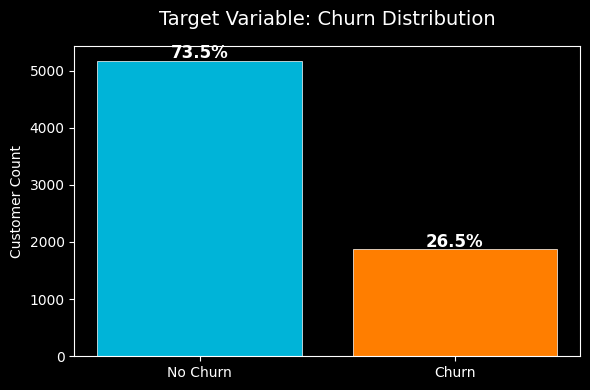

In [67]:
# Target variable distribution — CRITICAL first check
# WHY: if churn is 5% of data, accuracy is useless as a metric
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
print(pd.DataFrame({'count': churn_counts, 'percentage': churn_pct.round(1)}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Churn', 'Churn'], churn_counts.values, 
               color=['#00b4d8', '#ff7e00'], edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Target Variable: Churn Distribution', fontsize=14, pad=15)
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.savefig('../assets/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# KEY INSIGHT to note: ~26% churn = moderately imbalanced
# class_weight or SMOTE in modeling is required

## Data Cleaning

The Telco dataset has one known issue: `TotalCharges` is stored as a string (object dtype)  
even though it should be numeric.

In [68]:
# Fix 1: TotalCharges is object dtype — convert to numeric
# WHY it's object: some rows have a space (' ') instead of a number (new customers with 0 tenure)
print('TotalCharges sample values with spaces:')
print(df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# These are new customers (tenure=0) — fill with 0 is logical
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f'\nTotalCharges nulls after fix: {df["TotalCharges"].isnull().sum()}')
print(f'TotalCharges dtype: {df["TotalCharges"].dtype}')

TotalCharges sample values with spaces:
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             

TotalCharges nulls after fix: 0
TotalCharges dtype: float64


In [69]:
# Fix 2: Encode target variable as binary (0/1)
# WHY: helps ML models'
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Fix 3: Drop customerID — it's an identifier, not a feature
# WHY: IDs have no predictive signal and can cause data leakage
df = df.drop('customerID', axis=1)

print(f'Cleaned shape: {df.shape}')
print(f'Churn encoded: {df["Churn"].unique()}')

Cleaned shape: (7043, 20)
Churn encoded: [0 1]


## Exploratory Analysis

This section answers: **which features are most associated with churn?**  
This guides feature engineering i.e. don't engineer blindly, engineer based on signal.

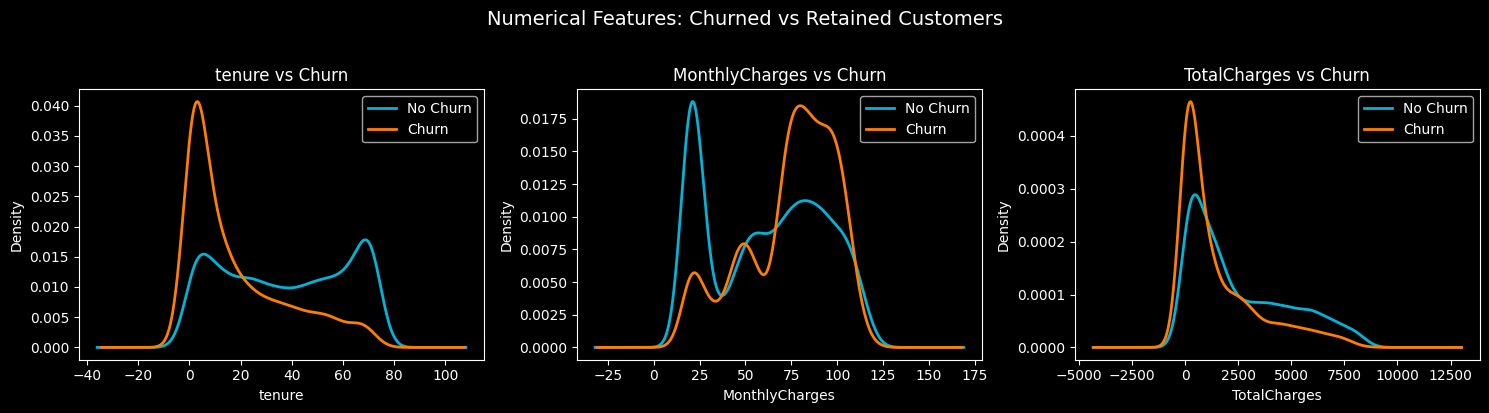

In [70]:
# Numerical features vs Churn — used KDE plots to see distribution shift
# WHY KDE over histograms: shows shape of distribution, easier to compare churned vs not

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df[df['Churn'] == 0][col].plot.kde(ax=ax, label='No Churn', color='#00b4d8', linewidth=2)
    df[df['Churn'] == 1][col].plot.kde(ax=ax, label='Churn', color='#ff7e00', linewidth=2)
    ax.set_title(f'{col} vs Churn', fontsize=12)
    ax.legend()
    ax.set_xlabel(col)

plt.suptitle('Numerical Features: Churned vs Retained Customers', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../assets/numerical_kde.png', dpi=150, bbox_inches='tight')
plt.show()

tenure : Number of months the customer has stayed with the company.  
MonthlyCharges : The amount charged to the customer monthly.  
TotalCharges : The total amount charged to the customer.  

**Note the plot above**
1. **tenure: churners have LOW tenure (they leave early)**
2. **MonthlyCharges: churners pay MORE per month**
3. **TotalCharges: churners have LOW total (because they leave before accumulating)**

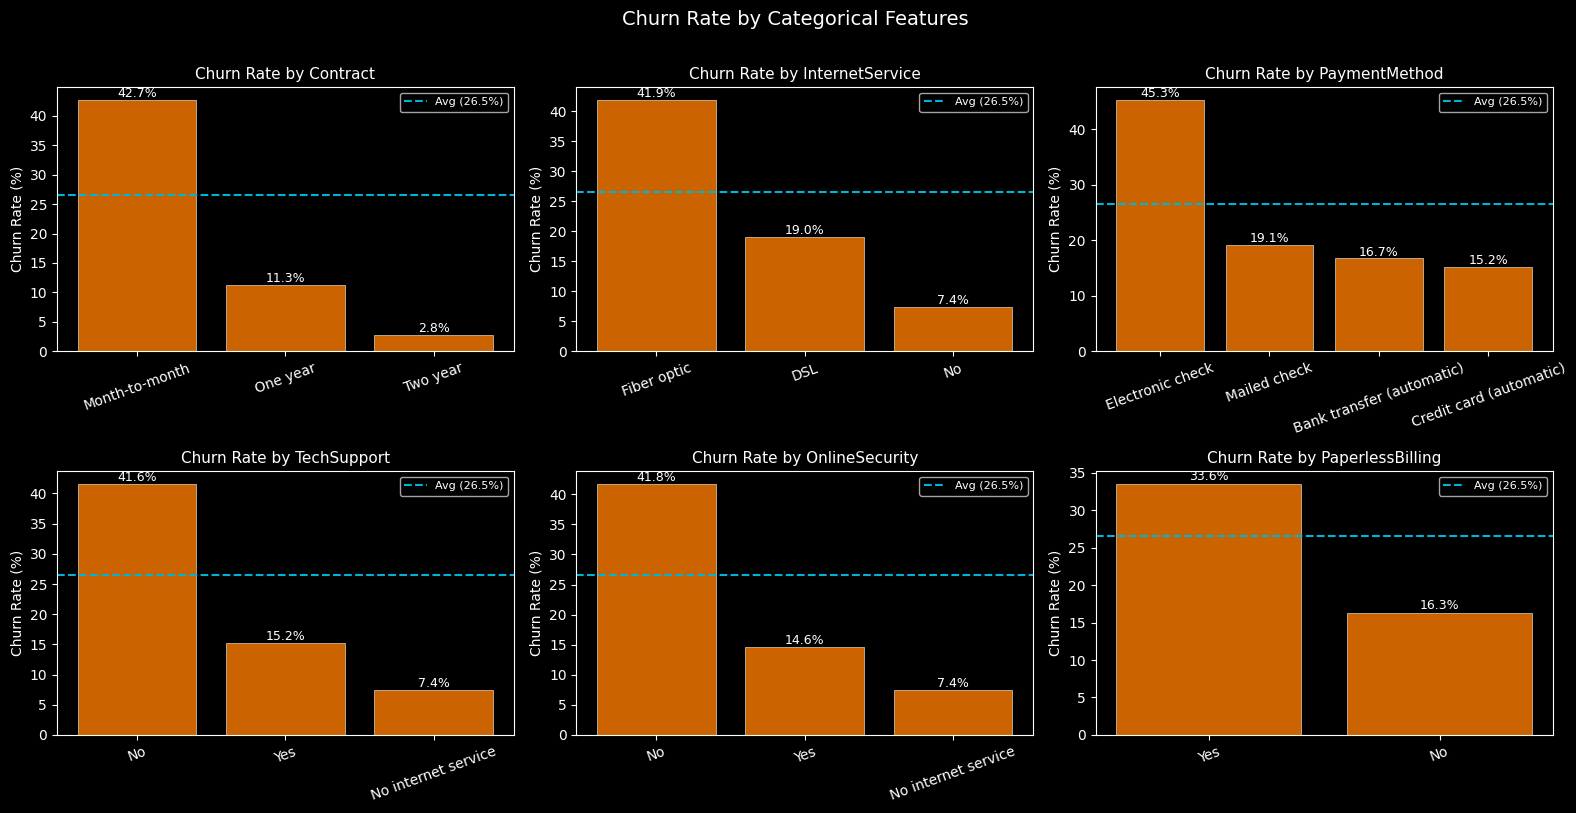

In [71]:
# Categorical features vs Churn — churn rate per category
# WHY: we want to see which service/contract types correlate with churn

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                   color='#ff7e00', alpha=0.8, edgecolor='white', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)
    ax.set_title(f'Churn Rate by {col}', fontsize=11)
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(y=df['Churn'].mean()*100, color='#00b4d8', 
               linestyle='--', linewidth=1.5, label=f'Avg ({df["Churn"].mean()*100:.1f}%)')
    ax.legend(fontsize=8)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../assets/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()


**KEY INSIGHTS:**
1. Month-to-month contracts churn at ~42% vs 2-year at ~3%
2. Fiber optic internet users churn more than DSL
3. No TechSupport/OnlineSecurity → much higher churn

## Feature Engineering

This is where I create NEW features that the model can't derive on its own.

**Rule:** Every engineered feature should have a business reason, not just a statistical one.

In [72]:
df_feat = df.copy()

# --- Feature 1: Charges per month of tenure ---
# WHY: A customer paying $80/month after 1 month is very different from
# one paying $80/month after 3 years. Normalizes by loyalty.
df_feat['ChargesPerTenureMonth'] = df_feat['MonthlyCharges'] / (df_feat['tenure'] + 1)

# --- Feature 2: Total services subscribed ---
# WHY: Customers with more services have higher switching costs
# This is a classic telco retention insight
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
# Convert Yes/No to 1/0 for summing
for col in service_cols:
    df_feat[col + '_bin'] = (df_feat[col] == 'Yes').astype(int)

df_feat['TotalServices'] = df_feat[[c + '_bin' for c in service_cols]].sum(axis=1)

# --- Feature 3: Is new customer (tenure <= 6 months) ---
# WHY: First 6 months is the highest-risk churn window in telecom
df_feat['IsNewCustomer'] = (df_feat['tenure'] <= 6).astype(int)

# --- Feature 4: Is long-term customer (tenure > 36 months) ---
# WHY: 3+ year customers are highly loyal — very low churn risk
df_feat['IsLongTermCustomer'] = (df_feat['tenure'] > 36).astype(int)

# --- Feature 5: High value customer flag ---
# WHY: High monthly charge + long tenure = most valuable segment to retain
monthly_median = df_feat['MonthlyCharges'].median()
tenure_median = df_feat['tenure'].median()
df_feat['IsHighValue'] = (
    (df_feat['MonthlyCharges'] > monthly_median) & 
    (df_feat['tenure'] > tenure_median)
).astype(int)

# --- Feature 6: Contract risk score ---
# WHY: Encodes the ordinal risk directly (month-to-month = highest churn risk)
contract_risk = {'Month-to-month': 3, 'One year': 2, 'Two year': 1}
df_feat['ContractRisk'] = df_feat['Contract'].map(contract_risk)

print('New features created:')
new_feats = ['ChargesPerTenureMonth', 'TotalServices', 'IsNewCustomer', 
             'IsLongTermCustomer', 'IsHighValue', 'ContractRisk']
print(df_feat[new_feats + ['Churn']].describe().round(2))

New features created:
       ChargesPerTenureMonth  TotalServices  IsNewCustomer  \
count                7043.00        7043.00        7043.00   
mean                    5.77           3.36           0.21   
std                     8.72           2.06           0.41   
min                     0.26           0.00           0.00   
25%                     1.25           1.00           0.00   
50%                     2.08           3.00           0.00   
75%                     5.95           5.00           0.00   
max                    80.85           8.00           1.00   

       IsLongTermCustomer  IsHighValue  ContractRisk   Churn  
count             7043.00      7043.00       7043.00 7043.00  
mean                 0.43         0.29          2.31    0.27  
std                  0.49         0.45          0.83    0.44  
min                  0.00         0.00          1.00    0.00  
25%                  0.00         0.00          2.00    0.00  
50%                  0.00         0.00   

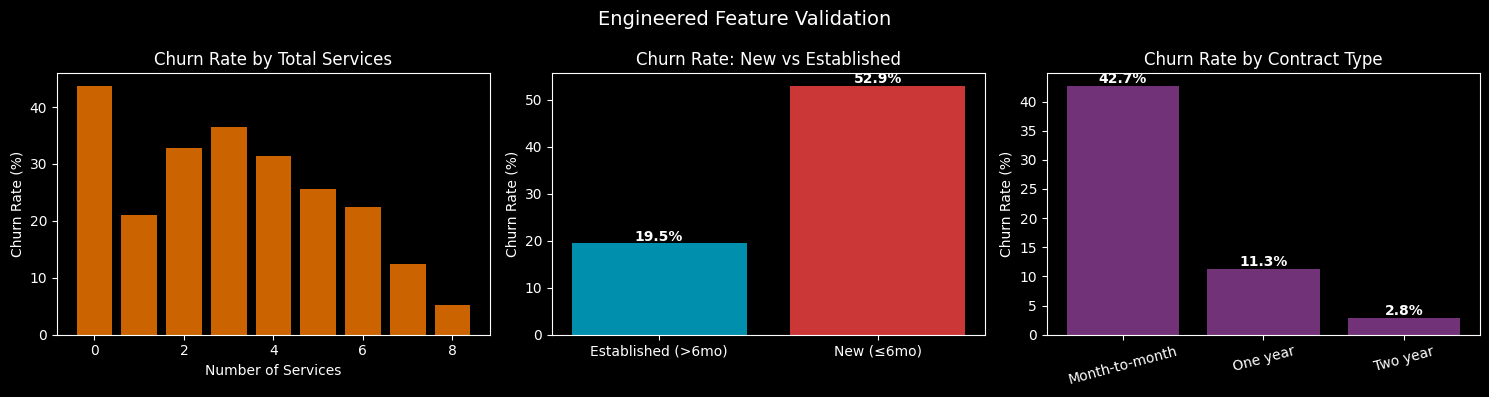

In [73]:
# Validate that engineered features actually correlate with churn

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TotalServices vs churn rate
services_churn = df_feat.groupby('TotalServices')['Churn'].mean() * 100
axes[0].bar(services_churn.index, services_churn.values, color='#ff7e00', alpha=0.8)
axes[0].set_title('Churn Rate by Total Services')
axes[0].set_xlabel('Number of Services')
axes[0].set_ylabel('Churn Rate (%)')

# IsNewCustomer vs churn
new_cust_churn = df_feat.groupby('IsNewCustomer')['Churn'].mean() * 100
axes[1].bar(['Established (>6mo)', 'New (≤6mo)'], new_cust_churn.values, 
             color=['#00b4d8', '#ff4444'], alpha=0.8)
axes[1].set_title('Churn Rate: New vs Established')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(new_cust_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ContractRisk vs churn
contract_churn = df_feat.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
axes[2].bar(contract_churn.index, contract_churn.values, color='#8f3f97', alpha=0.8)
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(contract_churn.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Engineered Feature Validation', fontsize=14)
plt.tight_layout()
plt.savefig('../assets/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Encode Categoricals & Save Clean Dataset

The final feature matrix for modeling.  
I have used Label Encoding for binary columns and One-Hot for multi-class columns.

In [74]:
from sklearn.preprocessing import LabelEncoder

df_model = df_feat.copy()

# Drop the binary _bin columns we used for TotalServices (already encoded)
bin_cols = [c + '_bin' for c in service_cols]
df_model = df_model.drop(columns=bin_cols)

# Identify remaining categorical columns
cat_remaining = df_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_remaining}')

# Binary categoricals (Yes/No, Male/Female) → Label Encode
binary_cats = [c for c in cat_remaining 
               if df_model[c].nunique() == 2]
print(f'Binary (Label Encode): {binary_cats}')

le = LabelEncoder()
for col in binary_cats:
    df_model[col] = le.fit_transform(df_model[col])

# Multi-class categoricals → One-Hot Encode
multi_cats = [c for c in cat_remaining 
              if df_model[c].nunique() > 2 and c in df_model.columns]
print(f'Multi-class (One-Hot): {multi_cats}')

df_model = pd.get_dummies(df_model, columns=multi_cats, drop_first=True)

print(f'\nFinal feature matrix shape: {df_model.shape}')
print(f'Features: {df_model.columns.tolist()}')

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Binary (Label Encode): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class (One-Hot): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Final feature matrix shape: (7043, 37)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ChargesPerTenureMonth', 'TotalServices', 'IsNewCustomer', 'IsLongTermCustomer', 'IsHighValue', 'ContractRisk', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet se

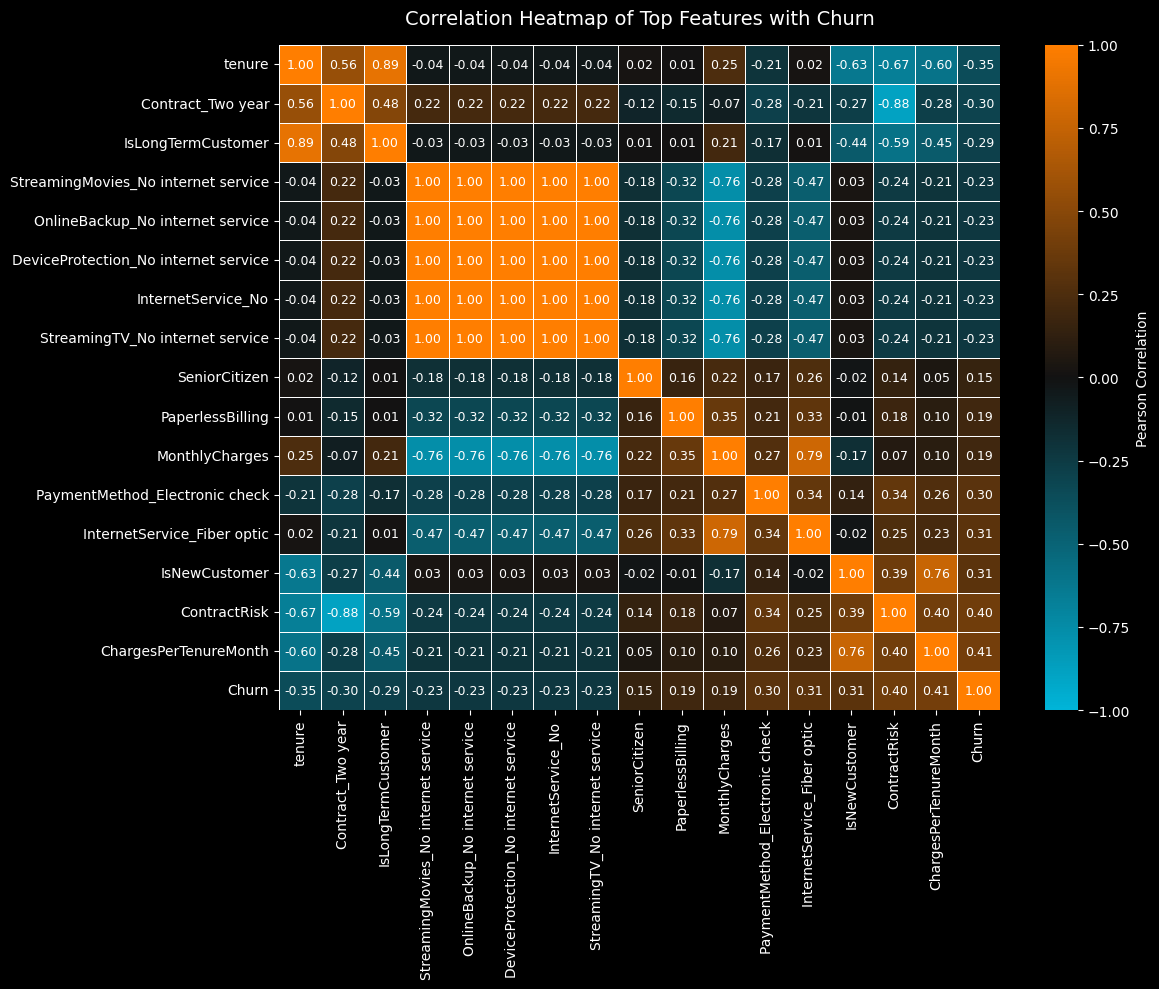


Top positive correlations (increase churn risk):
PaymentMethod_Electronic check   0.30
InternetService_Fiber optic      0.31
IsNewCustomer                    0.31
ContractRisk                     0.40
ChargesPerTenureMonth            0.41
Name: Churn, dtype: float64

Top negative correlations (decrease churn risk):
tenure                                -0.35
Contract_Two year                     -0.30
IsLongTermCustomer                    -0.28
StreamingMovies_No internet service   -0.23
OnlineBackup_No internet service      -0.23
Name: Churn, dtype: float64


In [75]:
# Correlation heatmap of top features with Churn
# WHY: Quick visual of what the model will likely find important

corr_with_churn = df_model.corr()['Churn'].drop('Churn').sort_values()
top_corr = pd.concat([corr_with_churn.head(8), corr_with_churn.tail(8)])

# Select the top correlated features plus Churn for the 2D heatmap
top_features = top_corr.index.tolist() + ['Churn']
corr_matrix = df_model[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

# Custom colormap matching the theme: cyan for negative, orange for positive, dark center
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('cyan_orange', ['#00b4d8', '#121212', '#ff7e00'])

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation'},
    linewidths=0.5,
    annot_kws={'size': 9}
)

ax.set_title('Correlation Heatmap of Top Features with Churn', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../assets/correlation_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop positive correlations (increase churn risk):')
print(corr_with_churn.tail(5).round(3))
print('\nTop negative correlations (decrease churn risk):')
print(corr_with_churn.head(5).round(3))


In [76]:
# Saved clean dataset for Part 2 modeling
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

df_model.to_csv('../data/telco_churn_clean.csv', index=False)
print(f'Clean dataset saved → data/telco_churn_clean.csv')
print(f'Shape: {df_model.shape}')
print(f'Target (Churn) distribution:\n{df_model["Churn"].value_counts()}')

# Quick summary for your own notes
print('\n=== Part 1 Summary ===')
print(f'Total customers: {len(df_model)}')
print(f'Churn rate: {df_model["Churn"].mean()*100:.1f}%')
print(f'Features after engineering: {df_model.shape[1] - 1}')
print(f'New features added: ChargesPerTenureMonth, TotalServices, IsNewCustomer, IsLongTermCustomer, IsHighValue, ContractRisk')
print(f'Key insight: Month-to-month contract customers churn at ~42% vs 3% for 2-year contracts')

Clean dataset saved → data/telco_churn_clean.csv
Shape: (7043, 37)
Target (Churn) distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

=== Part 1 Summary ===
Total customers: 7043
Churn rate: 26.5%
Features after engineering: 36
New features added: ChargesPerTenureMonth, TotalServices, IsNewCustomer, IsLongTermCustomer, IsHighValue, ContractRisk
Key insight: Month-to-month contract customers churn at ~42% vs 3% for 2-year contracts
